# Machine Learning for Time Series

## Overview

ML models (Random Forest, Gradient Boosting, neural networks) can be applied to time series by engineering lag features and rolling statistics as predictors. This approach is called supervised/tabular forecasting.

**Advantages over ARIMA:**
- Handles non-linear relationships and interactions
- Can incorporate external regressors naturally
- No stationarity requirement

**Disadvantages:**
- No built-in uncertainty quantification
- Requires careful feature engineering
- Cannot extrapolate beyond the range of training targets
- Walk-forward CV is mandatory — random splits leak future data

**Key principle:** Transform the forecasting problem into a supervised learning problem using lag features, then treat temporal ordering as a constraint on valid train/test splits.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

rng = np.random.default_rng(42)
dates = pd.date_range("2010-01-01", periods=180, freq="MS")
trend    = np.linspace(2.5, 4.5, 180)
seasonal = 0.8*np.sin(2*np.pi*np.arange(180)/12)
noise    = rng.normal(0, 0.25, 180)
ts = pd.Series(trend+seasonal+noise, index=dates, name="nitrate")
print(f"Series: {len(ts)} monthly observations")

Series: 180 monthly observations


---
## Feature Engineering: Lags and Rolling Statistics

In [2]:
def make_features(series, lags=12, windows=[3,6,12]):
    df = pd.DataFrame({"target": series})
    # Lag features
    for lag in range(1, lags+1):
        df[f"lag_{lag:02d}"] = series.shift(lag)
    # Rolling statistics
    for w in windows:
        df[f"roll_mean_{w}"] = series.shift(1).rolling(w).mean()
        df[f"roll_std_{w}"]  = series.shift(1).rolling(w).std()
    # Calendar features
    df["month"] = series.index.month
    df["month_sin"] = np.sin(2*np.pi*df["month"]/12)
    df["month_cos"] = np.cos(2*np.pi*df["month"]/12)
    return df.dropna()

df_feat = make_features(ts)
print(f"Feature matrix: {df_feat.shape}")
print(f"Features: {[c for c in df_feat.columns if c != 'target'][:8]}...")
X = df_feat.drop("target", axis=1)
y = df_feat["target"]

Feature matrix: (168, 22)
Features: ['lag_01', 'lag_02', 'lag_03', 'lag_04', 'lag_05', 'lag_06', 'lag_07', 'lag_08']...


---
## Walk-Forward Train/Test Split

In [3]:
# Strict temporal split: all training data precedes all test data
HORIZON = 24
X_tr, X_te = X.iloc[:-HORIZON], X.iloc[-HORIZON:]
y_tr, y_te = y.iloc[:-HORIZON], y.iloc[-HORIZON:]
print(f"Train: {X_tr.shape}, Test: {X_te.shape}")
print(f"Train ends: {X_tr.index[-1].date()}, Test starts: {X_te.index[0].date()}")
print("\nCritical: no random shuffling -- temporal order must be preserved")

Train: (144, 21), Test: (24, 21)
Train ends: 2022-12-01, Test starts: 2023-01-01

Critical: no random shuffling -- temporal order must be preserved


---
## Fitting and Forecasting

Random Forest       : RMSE=0.2572, MAE=0.2038
Gradient Boosting   : RMSE=0.2949, MAE=0.2389


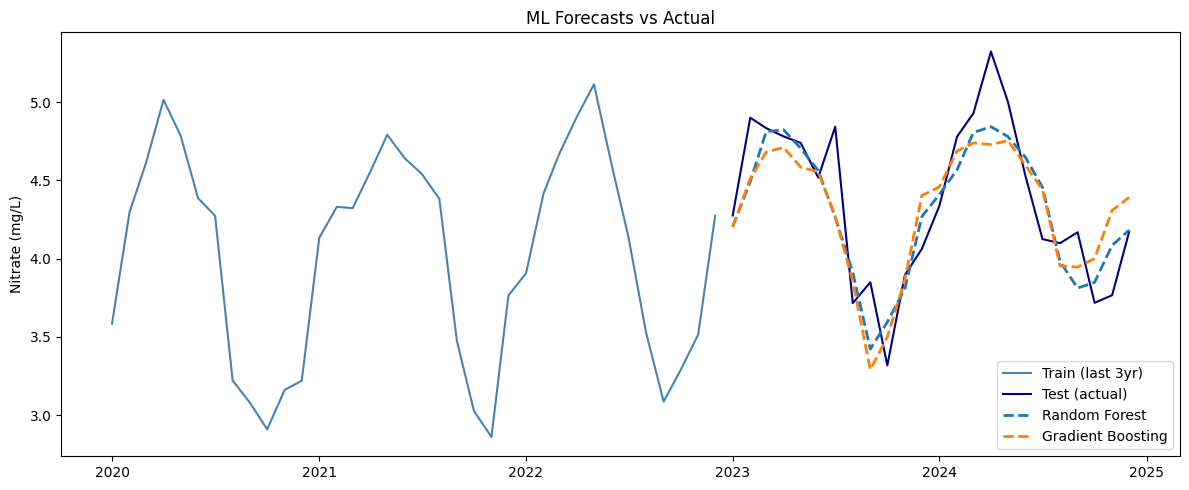

In [4]:
rf = RandomForestRegressor(n_estimators=300, max_features=0.5,
                            random_state=42, n_jobs=-1)
hgb = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05,
                                     max_depth=4, random_state=42)
results = {}
for name, model in [("Random Forest", rf), ("Gradient Boosting", hgb)]:
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    results[name] = pred
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    mae  = mean_absolute_error(y_te, pred)
    print(f"{name:20s}: RMSE={rmse:.4f}, MAE={mae:.4f}")
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(y_tr.index[-36:], y_tr.iloc[-36:], color="steelblue", lw=1.5, label="Train (last 3yr)")
ax.plot(y_te.index, y_te, color="navy", lw=1.5, label="Test (actual)")
for name, pred in results.items():
    ax.plot(y_te.index, pred, lw=2, linestyle="--", label=name)
ax.set_ylabel("Nitrate (mg/L)"); ax.set_title("ML Forecasts vs Actual")
ax.legend(); plt.tight_layout(); plt.show()

---
## Walk-Forward Cross-Validation

In [5]:
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5, test_size=12)
rf_cv_errors = []
for fold, (tr_idx, te_idx) in enumerate(tscv.split(X)):
    X_tr_cv, X_te_cv = X.iloc[tr_idx], X.iloc[te_idx]
    y_tr_cv, y_te_cv = y.iloc[tr_idx], y.iloc[te_idx]
    rf_cv = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    rf_cv.fit(X_tr_cv, y_tr_cv)
    pred_cv = rf_cv.predict(X_te_cv)
    mae_cv = mean_absolute_error(y_te_cv, pred_cv)
    rf_cv_errors.append(mae_cv)
    print(f"Fold {fold+1}: train={len(tr_idx)}, test={len(te_idx)}, MAE={mae_cv:.4f}")
print(f"\nMean CV MAE: {np.mean(rf_cv_errors):.4f} +/- {np.std(rf_cv_errors):.4f}")

Fold 1: train=108, test=12, MAE=0.4558
Fold 2: train=120, test=12, MAE=0.2878
Fold 3: train=132, test=12, MAE=0.3548
Fold 4: train=144, test=12, MAE=0.2276
Fold 5: train=156, test=12, MAE=0.2155

Mean CV MAE: 0.3083 +/- 0.0889


---

## Common Pitfalls

**1. Using random k-fold CV for time series ML models**  
Random splits allow future observations to appear in training data. A lag_1 feature computed from a future row leaks the answer. Always use `TimeSeriesSplit` or a manual walk-forward scheme that guarantees the training set ends before the test set begins.

**2. Including the target value in lag features without shifting**  
Lag features must be computed with `shift(lag)` — a lag of 1 uses yesterday's value to predict today. Forgetting the shift creates a feature that is the target itself, producing perfect in-sample fit and zero out-of-sample accuracy.

**3. Using calendar month as a raw integer feature (1–12)**  
Month as an integer implies a linear relationship (December=12 is numerically distant from January=1, but seasonally adjacent). Encode month as sine/cosine features to preserve cyclical structure.

**4. Not assessing feature importance for lag selection**  
Including 24 lag features when only lags 1, 3, and 12 are informative adds noise and can hurt RF performance. Use permutation importance to identify which lags are genuinely predictive and trim accordingly.

**5. Treating ML forecast uncertainty as negligible because no CI is produced**  
ML regressors produce point forecasts without built-in uncertainty estimates. Use quantile regression forests or conformal prediction intervals to quantify forecast uncertainty — do not report point forecasts as if they were certain.

---
*python_methods_library - Samantha McGarrigle*